#**Projeto: Agrupamento de Dados do Censo da Califórnia com K-Means**

#Objetivo

O objetivo deste projeto é utilizar o algoritmo K-Means para identificar grupos semelhantes de regiões da Califórnia com base em características socioeconômicas e habitacionais presentes no conjunto de dados California Housing. Por meio da clusterização, busca-se descobrir padrões ocultos nos dados sem utilizar informações prévias de classificação.

Importação das Bibliotecas


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

Carregamento dos Dados

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Exploração Inicial dos Dados

Dimensões

In [ ]:
print("Linhas e Colunas:")
print(df.shape)

Linhas e Colunas:
(20640, 10)


Informações Gerais

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


Valores Ausentes

In [ ]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


Estatísticas Descritivas

In [ ]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

Visualização dos Dados

Histograma das Variáveis

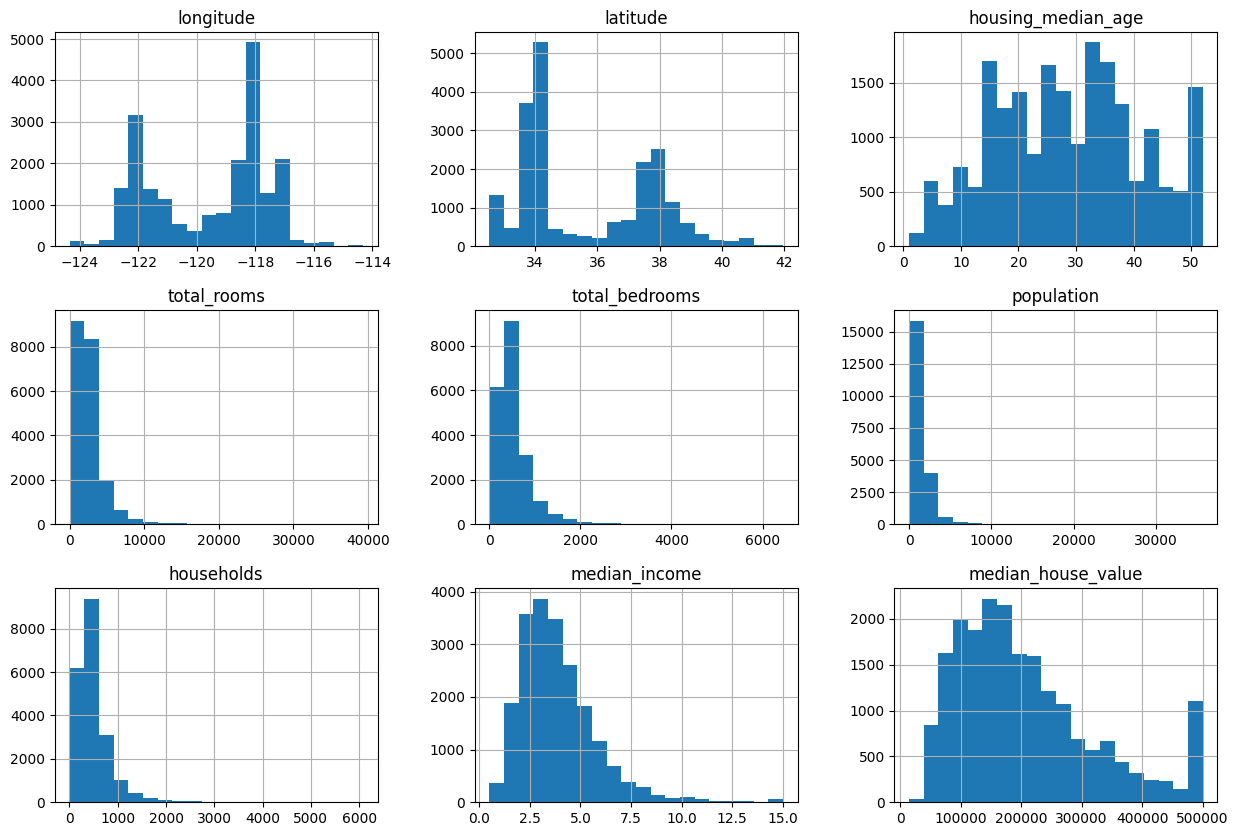

In [ ]:
df.hist(figsize=(15,10), bins=20)
plt.show()

Matriz de Correlação

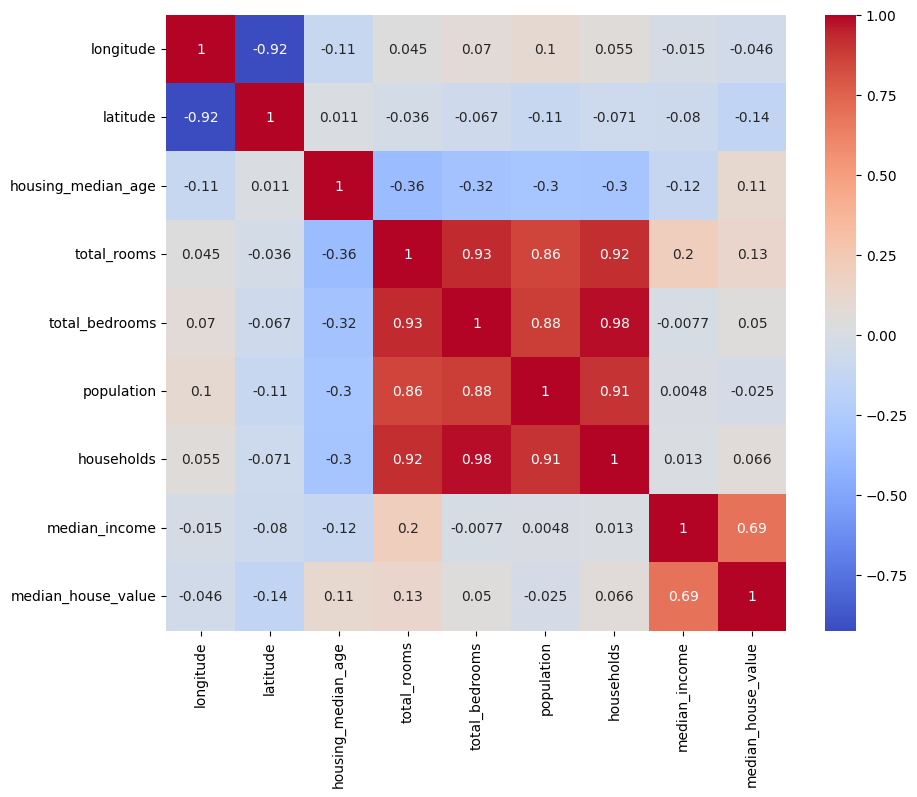

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap( df.drop('ocean_proximity', axis=1).corr(), annot=True, cmap="coolwarm")
plt.show()



Padronização dos Dados

Como o K-Means utiliza distância euclidiana, é necessário padronizar os dados.

In [51]:
imputer = SimpleImputer(strategy='mean')
dados_imputados = imputer.fit_transform(df.drop('ocean_proximity', axis=1))
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(dados_imputados)

Método do Cotovelo

Utilizado para determinar a quantidade ideal de clusters.

In [52]:
imputer = SimpleImputer(strategy='mean')
dados_padronizados = scaler.fit_transform(dados_imputados)

inercia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(dados_padronizados)
    inercia.append(kmeans.inertia_)

Gráfico do Cotovelo

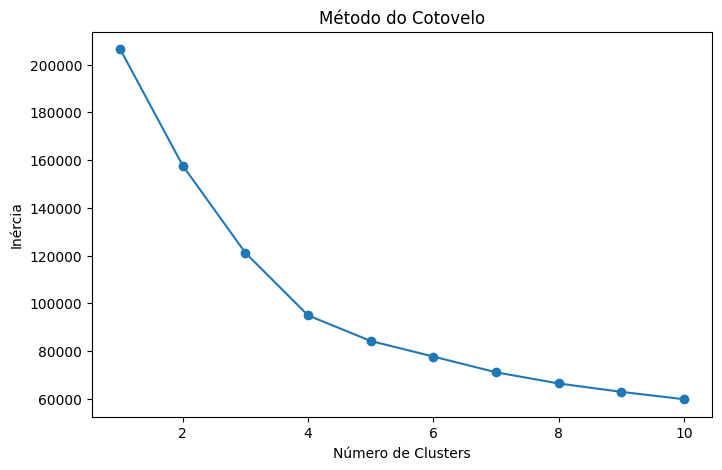

In [53]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inercia, marker="o")
plt.xlabel("Número de Clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")

plt.show()

Silhouette Score para validar K

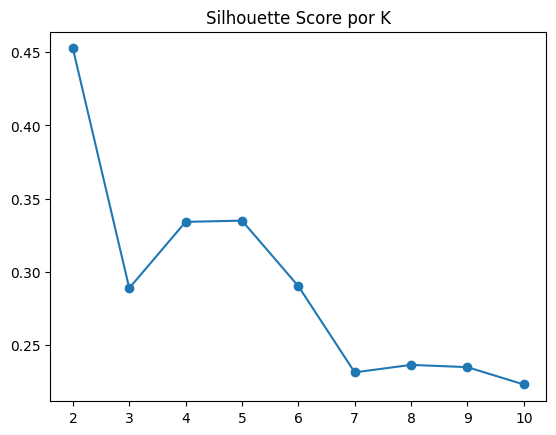

In [54]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(dados_padronizados)
    scores.append(silhouette_score(dados_padronizados, labels))

plt.plot(range(2, 11), scores, marker='o')
plt.title('Silhouette Score por K')
plt.show()

Observando o gráfico, a curva de inércia apresenta uma queda acentuada até K=3, e a partir de K=4 o ganho começa a diminuir significativamente — o "cotovelo" está entre K=3 e K=4.

Removendo variáveis multicolineares

In [55]:
# total_bedrooms e households são quase redundantes com total_rooms
# Remover pode melhorar a qualidade dos clusters
features = ['longitude', 'latitude', 'housing_median_age',
            'median_income', 'median_house_value', 'population']

Aplicação do K-Means

K = 4:

In [56]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(dados_padronizados)

df["Cluster"] = clusters

Quantidade de Registros por Cluster

In [57]:
print(df["Cluster"].value_counts())

Cluster
0    8896
2    7144
3    3048
1    1552
Name: count, dtype: int64


Características de Cada Cluster

In [58]:
analise_clusters = df.drop('ocean_proximity', axis=1).groupby("Cluster").mean()

print(analise_clusters)

          longitude   latitude  housing_median_age  total_rooms  \
Cluster                                                           
0       -117.974555  33.947913           29.680868  2086.997302   
1       -119.193512  35.289729           16.412371  7994.367912   
2       -121.660087  38.021880           29.484742  2120.277436   
3       -119.517411  35.119101           29.844816  2717.093504   

         total_bedrooms   population   households  median_income  \
Cluster                                                            
0            463.319695  1320.324978   433.127810       3.280918   
1           1609.821429  4086.044459  1470.121134       4.122070   
2            436.356880  1110.594065   403.333427       3.302778   
3            446.253316  1115.683727   424.656168       6.794982   

         median_house_value  
Cluster                      
0             171511.634667  
1             216123.547680  
2             163890.258539  
3             405997.639764  


Visualização dos Clusters

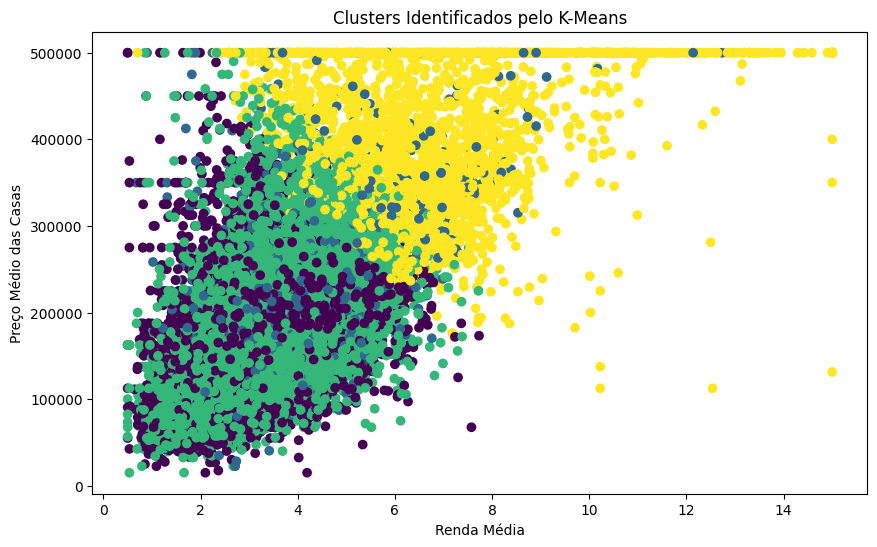

In [59]:
plt.figure(figsize=(10,6))
plt.scatter(df["median_income"], df["median_house_value"], c=df["Cluster"], cmap="viridis")
plt.xlabel("Renda Média")
plt.ylabel("Preço Médio das Casas")
plt.title("Clusters Identificados pelo K-Means")

plt.show()

Mapa Geográfico

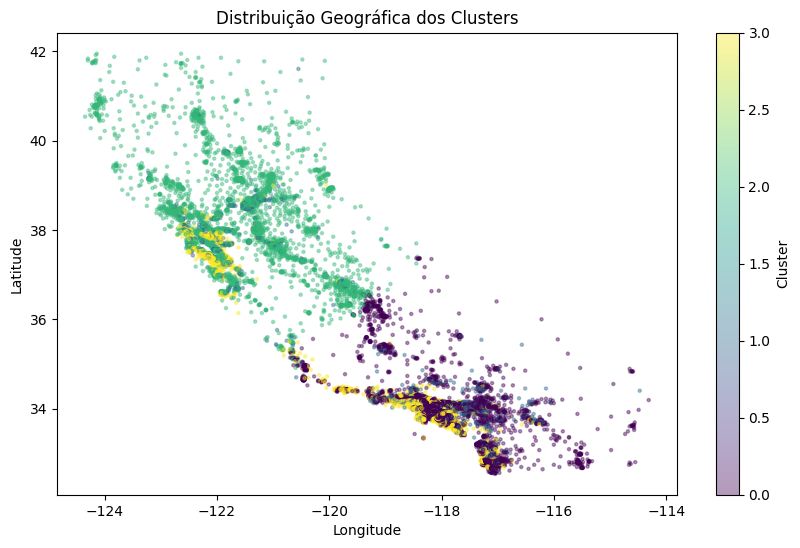

In [60]:
plt.figure(figsize=(10, 6))
plt.scatter(df["longitude"], df["latitude"], c=df["Cluster"], cmap="viridis", alpha=0.4, s=5)
plt.colorbar(label="Cluster")
plt.title("Distribuição Geográfica dos Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

#Análise Completa do Projeto K-Means — Housing

Análise Exploratória dos Dados (EDA)

Distribuições (Histogramas)

longitude/latitude: dois picos visíveis, refletindo as duas grandes regiões da Califórnia, Bay Area (norte) e Los Angeles (sul)

total_rooms, total_bedrooms, population, households: distribuições com forte assimetria à direita (skewed), com outliers expressivos

median_income: distribuição aproximadamente normal entre 0–10, com cauda longa

median_house_value: distribuição relativamente uniforme até aproximadamente 500k dólares, com pico no teto de 500.001 dólares, indicando censura artificial nos dados (valores acima desse limite foram truncados)

housing_median_age: distribuição bimodal, sugerindo bairros antigos e novos bem distintos

Matriz de Correlação
| Relação                            | Correlação | Interpretação                                      |
| ---------------------------------- | ---------- | -------------------------------------------------- |
| longitude ↔ latitude               | -0.92      | Alta correlação geográfica esperada                |
| total_rooms ↔ households           | 0.92       | Mais domicílios = mais cômodos                     |
| total_bedrooms ↔ households        | 0.98       | Multicolinearidade forte                           |
| median_income ↔ median_house_value | 0.69       | A renda explica boa parte do preço dos imóveis     |
| population ↔ total_rooms           | 0.86       | Áreas mais populosas tendem a possuir mais cômodos |


A alta multicolinearidade entre total_rooms, total_bedrooms, population e households significa que essas variáveis carregam informação redundante, isso pode distorcer o K-Means, que trata todas as features com peso igual.

Análise dos Clusters

Distribuição por Cluster
| Cluster   | Quantidade de Registros | Percentual |
| --------- | ----------------------- | ---------- |
| Cluster 1 | 8.896                   | 43%        |
| Cluster 0 | 7.144                   | 35%        |
| Cluster 2 | 3.048                   | 15%        |
| Cluster 3 | 1.552                   | 7%         |


Perfil de Cada Cluster
| Cluster | Registros | Renda Média | Preço Médio | Perfil |
|----------|----------|----------|----------|----------|
| 0 | 7145 | 3.30 | 163915 | Interior norte - renda e preco baixos |
| 1 | 3046 | 6.80 | 406009 | Alta renda, alto preco - regioes premium |
| 2 | 8895 | 3.28 | 171511 | Litoral sul densamente populoso |
| 3 | 1554 | 4.12 | 216239 | Blocos urbanos densos |


Interpretação Visual (Scatter Plot)

O gráfico Renda Média × Preço das Casas mostra:

Cluster 2 (verde): claramente separado à direita, alta renda e altos preços, boa separação

Clusters 0 e 1 (roxo/azul): muito sobrepostos, difícil distinção visual, provavelmente diferenciados pela geografia (longitude/latitude)

Cluster 3 (amarelo): espalhado, capturando grandes blocos urbanos pelo tamanho das unidades


O teto de $500k cria uma linha horizontal artificial no topo do gráfico, afetando o Cluster 2 desproporcionalmente.